# 1) Testing IDyOM Cross Validation 


## Extracting data from the BiMMuDA dataset

In [23]:
# import os
# import shutil

# source_root = "data/BiMMuDA"
# destination = "all_midis"

# os.makedirs(destination, exist_ok=True)

# for root, dirs, files in os.walk(source_root):
#     for file in files:
#         if file.endswith(".mid"):
#             src_path = os.path.join(root, file)
#             dst_path = os.path.join(destination, file)
#             shutil.copy2(src_path, dst_path)

### Clean the files to only include monophonic and non corrupted melody fragments

In [24]:
# import mido

# SOURCE_DIR = "all_midis"
# DEST_DIR = "clean_monophonic_midis"

# os.makedirs(DEST_DIR, exist_ok=True)

# def is_monophonic(midi_path):
#     try:
#         midi = mido.MidiFile(midi_path)
#     except Exception:
#         return False, "corrupted"

#     notes = []
#     current_time = 0

#     for track in midi.tracks:
#         current_time = 0
#         active_notes = {}

#         for msg in track:
#             current_time += msg.time

#             if msg.type == "note_on" and msg.velocity > 0 and msg.channel != 9:
#                 active_notes[msg.note] = current_time

#             elif (msg.type == "note_off") or (msg.type == "note_on" and msg.velocity == 0):
#                 if msg.note in active_notes:
#                     start = active_notes.pop(msg.note)
#                     end = current_time
#                     notes.append((start, end))

#     if len(notes) == 0:
#         return False, "no_notes"

#     # sort by start time
#     notes.sort(key=lambda x: x[0])

#     # check overlap
#     prev_end = notes[0][1]
#     for start, end in notes[1:]:
#         if start < prev_end:
#             return False, "polyphonic"
#         prev_end = max(prev_end, end)

#     return True, "monophonic"


# print("Cleaning MIDI dataset for IDyOM...\n")

# for file in os.listdir(SOURCE_DIR):
#     if file.endswith(".mid"):
        
#         # Skip files containing "full"
#         if "full" in file.lower():
#             print(f"Skipping {file} → contains 'full'")
#             continue
        
#         path = os.path.join(SOURCE_DIR, file)
#         ok, reason = is_monophonic(path)

#         if ok:
#             shutil.copy2(path, os.path.join(DEST_DIR, file))
#         else:
#             print(f"Skipping {file} → {reason}")

# print("\nDone.")

## Run the IDyOM cross validation function on the dataset

In [25]:
# ! python3 IDyOM/App.py -c clean_monophonic_midis/

### Add the resulting pickle file path below to inspect the data

In [26]:
import pickle

with open("out/eval/data/likelihoods_cross-eval_k_fold_5_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle", "rb") as f:
    data = pickle.load(f)

# print(type(data))

In [27]:
# print(data.keys())

## Convert to pandas dataframe to work with joining data

In [28]:
import pandas as pd

df = pd.DataFrame(data)
df

,2007_05_2,1994_04_1,2005_02_1,2001_05_1,1969_01_2,1991_01_3,1983_05_1,1970_04_2,2013_01_1,1978_04_2,...,1977_03_3,2010_05_3,2020_04_2,2008_01_2,2011_05_2,1969_02_2,2017_03_1,1960_05_2,2001_01_1,info
0,"[4.516480270205056, 3.2500684503633095, 4.7882...","[4.04403345931711, 5.442211984259578, 3.253372...","[4.234979496145881, 3.902638628962201, 3.40916...","[4.33746426547517, 4.359463448456414, 3.021119...","[5.013402927647211, 3.6121805299638914, 1.9704...","[3.9987459186963332, 4.820412912904651, 3.2024...","[5.236358275046125, 4.491862103757247, 3.20446...","[5.308482796591717, 5.469910446807136, 4.89387...","[4.033551083680571, 2.741922684381036, 2.55264...","[5.972207613293579, 2.776361677681063, 2.07749...",...,"[5.966815245577175, 4.638600777352498, 3.49517...","[4.1006147590367865, 9.674416303582388, 3.1832...","[3.9833480462958644, 5.573980200011228, 2.2260...","[4.245301634436269, 4.140517732168921, 2.73087...","[4.012807024211956, 4.682613083897336, 5.65416...","[4.740425764518198, 6.905797434282788, 4.47764...","[4.22621731795505, 4.727247856317818, 3.807374...","[4.03614526904113, 4.607840070327161, 2.457493...","[6.808723370532655, 5.451702494704331, 5.54131...",Each variable corresponds to a song. For each ...
1,"[4.73569841252648, 4.959952872069636, 4.207138...","[4.73569841252648, 5.132129147137926, 4.207155...","[4.73569841252648, 4.40031126411454, 4.2057256...","[4.73569841252648, 3.9547598787796634, 4.26529...","[4.73569841252648, 4.098876513457048, 4.231377...","[4.73569841252648, 4.940387869523069, 4.292785...","[4.73569841252648, 4.389229580615364, 4.247225...","[4.73569841252648, 4.751780935110515, 4.300529...","[4.73569841252648, 3.982733272564505, 4.217632...","[4.73569841252648, 4.480421512252237, 4.212455...",...,"[4.725227889482467, 4.631933801741046, 4.24897...","[4.725227889482467, 4.7371844271227115, 4.1198...","[4.725227889482467, 4.7992460108214186, 4.1819...","[4.725227889482467, 4.22123692823236, 4.280765...","[4.725227889482467, 3.5686794844662986, 4.2772...","[4.725227889482467, 4.15677944822524, 4.308557...","[4.731551948168222, 4.627539566834528, 4.23859...","[4.731551948168222, 4.518428159556651, 4.26964...","[4.731551948168222, 4.820671636518481, 4.24551...",Each variable corresponds to a song. For each ...


In [29]:
df = df.drop(columns=["info"])

In [30]:
import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song in df.columns:
    year = int(song[:4])  # extract year from filename
    
    surprisal_vector = df.loc[0, song]
    entropy_vector = df.loc[1, song]
    
    mean_surprisal = np.mean(surprisal_vector)
    mean_entropy = np.mean(entropy_vector)
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(yearly_stats)

    year  mean_surprisal  mean_entropy
0   1950        4.406358      3.138299
1   1951        4.781330      3.560367
2   1952        4.461024      3.403464
3   1953        4.960273      3.605045
4   1954        4.255583      3.329353
..   ...             ...           ...
70  2020        3.618874      2.931633
71  2021        3.152493      2.692932
72  2022        3.110473      2.689270
73  2023        3.499404      2.974384
74  2024        3.664309      3.016401

[75 rows x 3 columns]


In [31]:
# yearly_stats.to_csv('out/eval/data/likelihoods_cross-eval_k_fold_5_quantization_24_maxOrder_20_viewpoints_pitch_length.csv', index=False)

## Generate a pandas dataframe for the metadata

In [32]:
import pandas as pd

genre_df = pd.read_csv("data/BiMMuDa/metadata/bimmuda_per_song_metadata.csv")

# print(genre_df.head())

In [33]:
genre_df["year_position"] = (
    genre_df["Year"].astype(str)
    + "_"
    + genre_df["Position"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
    + genre_df["Position"].astype(str).str.extract(r"([a-zA-Z]+)")[0].fillna("")
)

In [34]:
genre_subset = genre_df[[
    "year_position",
    "Genre (Broad 1)",
    "Genre (Broad 2)",
    "Genre (Specific 1)",
    "Genre (Specific 2)",
    "Genre (Specific 3)"
]]

# genre_subset

In [35]:
# df.transpose()

In [36]:
songs = pd.Series(df.columns[:])  # skip "info" column

song_name_df = pd.DataFrame({
    "song": songs,
    "year_position": songs.str.extract(r"(\d{4}_\d{2})")[0]
})

# song_name_df

In [37]:
df_t = df.T.reset_index()
df_t.columns = ["year_position_raw", "surprisal", "entropy"]
df_t["year_position"] = df_t["year_position_raw"].str.rsplit("_", n=1).str[0]
# df_t

### Merge together metadata and the dataframe containing surprisal and entropy

In [38]:
merged_df = pd.merge(df_t, genre_subset, on="year_position", how= "left")
merged_df.drop(index=merged_df.index[-1],axis=0,inplace=True)

# Compute per-song means and map back to merged_df
merged_df["mean_surprisal"] = merged_df["surprisal"].apply(np.mean)
merged_df["mean_entropy"] = merged_df["entropy"].apply(np.mean)

merged_df

,year_position_raw,surprisal,entropy,year_position,Genre (Broad 1),Genre (Broad 2),Genre (Specific 1),Genre (Specific 2),Genre (Specific 3),mean_surprisal,mean_entropy
0,2007_05_2,"[4.516480270205056, 3.2500684503633095, 4.7882...","[4.73569841252648, 4.959952872069636, 4.207138...",2007_05,R&B,Hip-hop,Snap,NaN,NaN,4.378617,3.517372
1,1994_04_1,"[4.04403345931711, 5.442211984259578, 3.253372...","[4.73569841252648, 5.132129147137926, 4.207155...",1994_04,Pop,NaN,NaN,NaN,NaN,4.880874,3.412200
2,2005_02_1,"[4.234979496145881, 3.902638628962201, 3.40916...","[4.73569841252648, 4.40031126411454, 4.2057256...",2005_02,Hip-hop,NaN,NaN,NaN,NaN,2.838059,2.727959
3,2001_05_1,"[4.33746426547517, 4.359463448456414, 3.021119...","[4.73569841252648, 3.9547598787796634, 4.26529...",2001_05,R&B,Hip-hop,NaN,NaN,NaN,4.112367,2.974622
4,1969_01_2,"[5.013402927647211, 3.6121805299638914, 1.9704...","[4.73569841252648, 4.098876513457048, 4.231377...",1969_01,Pop,NaN,Bubblegum pop,NaN,NaN,2.618158,2.553817
...,...,...,...,...,...,...,...,...,...,...,...
1157,2008_01_2,"[4.245301634436269, 4.140517732168921, 2.73087...","[4.725227889482467, 4.22123692823236, 4.280765...",2008_01,Hip-hop,NaN,Crunk,Pop-rap,NaN,2.632525,2.353040
1158,2011_05_2,"[4.012807024211956, 4.682613083897336, 5.65416...","[4.725227889482467, 3.5686794844662986, 4.2772...",2011_05,EDM/Dance,Hip-hop,Hip house,Pop rap,NaN,2.909164,1.860560
1159,1969_02_2,"[4.740425764518198, 6.905797434282788, 4.47764...","[4.725227889482467, 4.15677944822524, 4.308557...",1969_02,Funk/Soul,NaN,Pyschedelic soul,NaN,NaN,4.961784,3.456743
1160,2017_03_1,"[4.22621731795505, 4.727247856317818, 3.807374...","[4.731551948168222, 4.627539566834528, 4.23859...",2017_03,Funk/Soul,R&B,NaN,NaN,NaN,2.857608,2.645661


In [39]:
# merged_df.to_csv('out/eval/data/merged_data.csv', index=False)

In [40]:
print(merged_df["Genre (Broad 1)"].value_counts())


Genre (Broad 1)
Pop          440
Rock         202
R&B          146
Funk/Soul    143
Hip-hop       82
Country       41
EDM/Dance     28
Rock          22
Folk          18
Jazz          17
Latin         12
Reggae        11
Name: count, dtype: int64


In [41]:
# merged_df[merged_df["Genre (Broad 1)"].isna()]

In [42]:
import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song, group in merged_df.groupby("year_position"):
    year = song[:4]  # extract year from filename

    mean_surprisal = np.mean([val for sublist in group["surprisal"] for val in sublist])
    mean_entropy = np.mean([val for sublist in group["entropy"] for val in sublist])
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

yearly_stats = pd.DataFrame(yearly_stats)

print(yearly_stats)

    year  mean_surprisal  mean_entropy
0   1950        4.407575      3.211373
1   1951        4.771719      3.567203
2   1952        4.407439      3.337397
3   1953        4.937063      3.591413
4   1954        4.226230      3.272265
..   ...             ...           ...
70  2020        3.635916      2.946720
71  2021        3.038605      2.625418
72  2022        3.126063      2.660467
73  2023        3.445590      2.935530
74  2024        3.556795      3.033799

[75 rows x 3 columns]


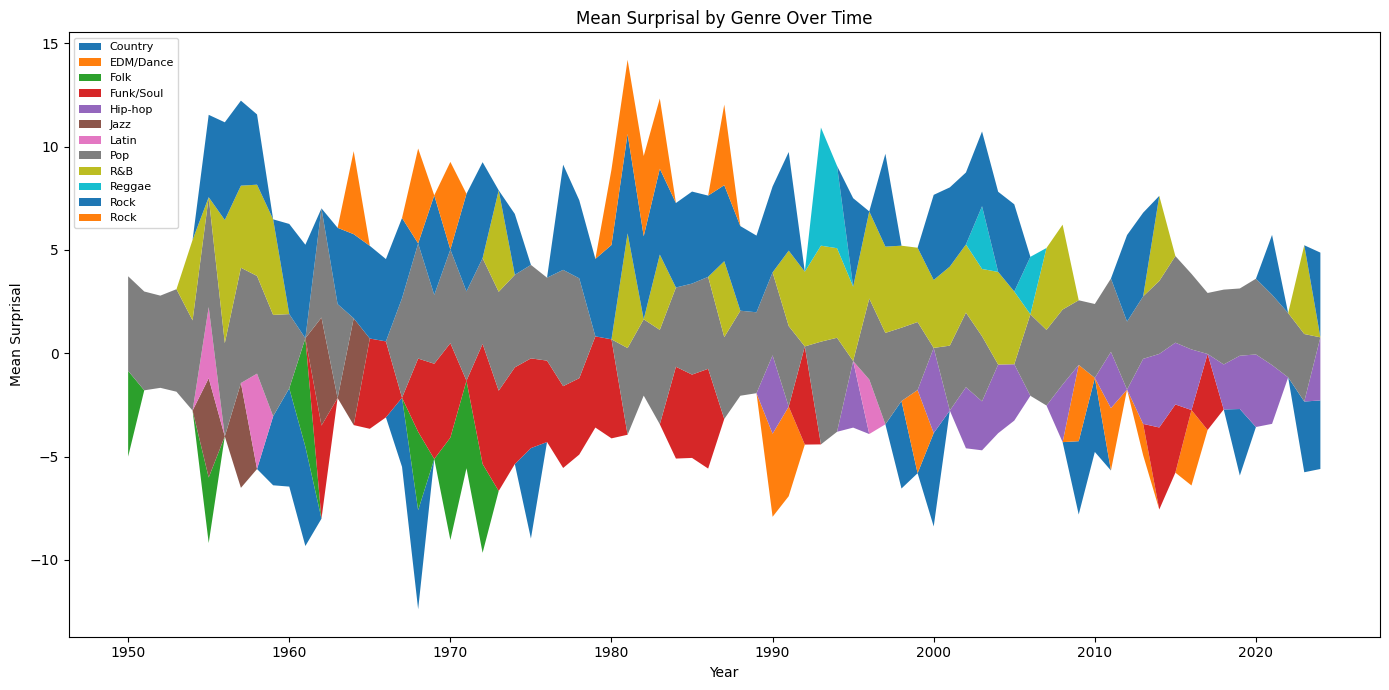

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Step 1: Extract year and aggregate by year + genre ---
merged_df["year"] = merged_df["year_position"].str[:4].astype(int)

yearly_genre = (
    merged_df.groupby(["year", "Genre (Broad 1)"])["mean_surprisal"]
    .mean()
    .reset_index()
)

# Pivot so genres are columns, years are rows
pivot_df = yearly_genre.pivot(index="year", columns="Genre (Broad 1)", values="mean_surprisal").fillna(0)

# --- Step 2: Plot streamgraph ---
years = pivot_df.index.values
genres = pivot_df.columns.tolist()
values = pivot_df.values.T  # shape: (n_genres, n_years)

fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(years, values, labels=genres, baseline="wiggle")  # "wiggle" gives the stream shape

ax.legend(loc="upper left", fontsize=8)
ax.set_title("Mean Surprisal by Genre Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Surprisal")

plt.tight_layout()
plt.show()

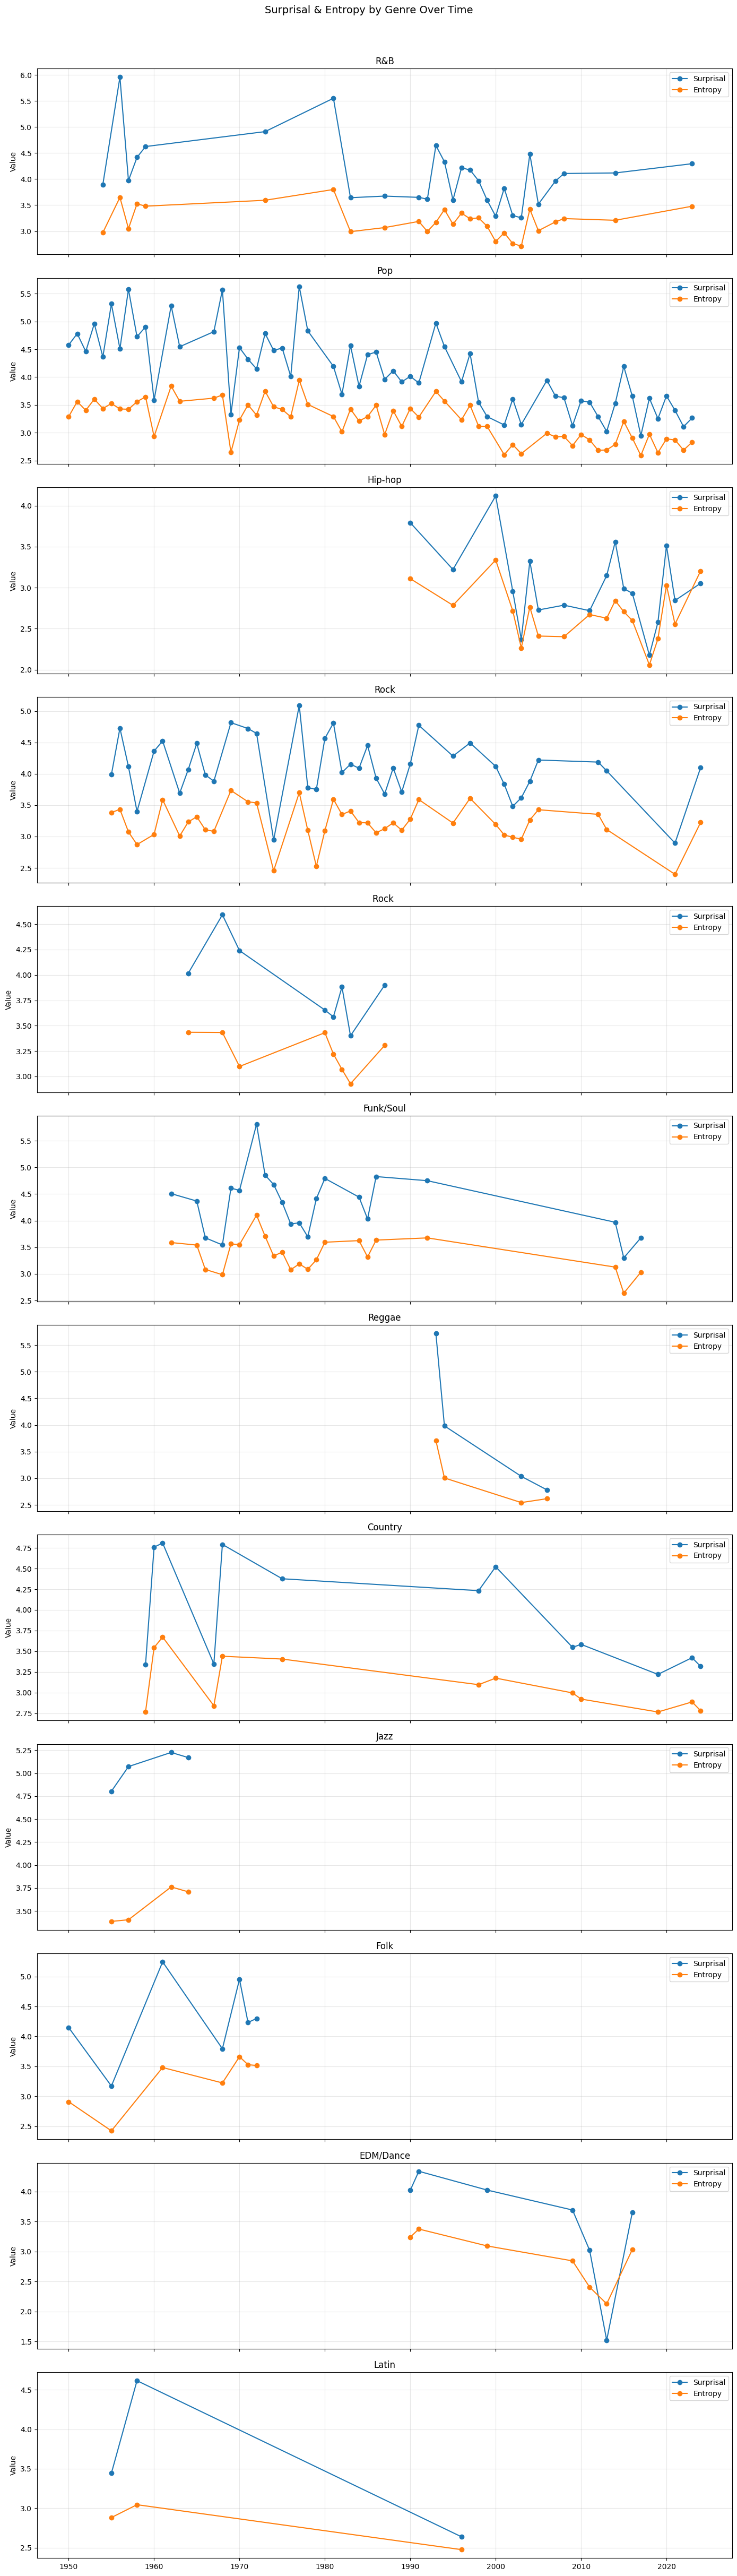

In [44]:
import matplotlib.pyplot as plt

genres = merged_df["Genre (Broad 1)"].dropna().unique()

fig, axes = plt.subplots(len(genres), 1, figsize=(14, 4 * len(genres)), sharex=True)

for ax, genre in zip(axes, genres):
    genre_df = merged_df[merged_df["Genre (Broad 1)"] == genre].copy()
    yearly = (
        genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    ax.plot(yearly["year"], yearly["mean_surprisal"], label="Surprisal", marker="o")
    ax.plot(yearly["year"], yearly["mean_entropy"], label="Entropy", marker="o")
    ax.set_title(genre)
    ax.set_ylabel("Value")
    # ax.set_xlabel("Year")
    ax.legend()
    ax.grid(True, alpha=0.3)

# axes[-1].set_xlabel("Year")
plt.suptitle("Surprisal & Entropy by Genre Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## to do: 

- try to get the PIC and RIC values replicated using the python implementation of IDyOM 

# Try incorporating long term memory on the evaluation 

- try testing a genre's perspective on another genre 
- try testing a rolling average to see which decade is more surprised by the other 


### Organize folders of training data

In [45]:
# ! python3 organize_midis_by_5yr.py -i TAR/midis -o tar_midis_by_5yr_window -w 4 -s 1

Found 1152 MIDI file(s) spanning 1950–2023.
  📁 1950-1954  →  64 file(s)
  📁 1951-1955  →  59 file(s)
  📁 1952-1956  →  59 file(s)
  📁 1953-1957  →  59 file(s)
  📁 1954-1958  →  65 file(s)
  📁 1955-1959  →  65 file(s)
  📁 1956-1960  →  68 file(s)
  📁 1957-1961  →  68 file(s)
  📁 1958-1962  →  72 file(s)
  📁 1959-1963  →  64 file(s)
  📁 1960-1964  →  65 file(s)
  📁 1961-1965  →  63 file(s)
  📁 1962-1966  →  65 file(s)
  📁 1963-1967  →  60 file(s)
  📁 1964-1968  →  61 file(s)
  📁 1965-1969  →  63 file(s)
  📁 1966-1970  →  64 file(s)
  📁 1967-1971  →  68 file(s)
  📁 1968-1972  →  68 file(s)
  📁 1969-1973  →  74 file(s)
  📁 1970-1974  →  74 file(s)
  📁 1971-1975  →  76 file(s)
  📁 1972-1976  →  78 file(s)
  📁 1973-1977  →  85 file(s)
  📁 1974-1978  →  84 file(s)
  📁 1975-1979  →  84 file(s)
  📁 1976-1980  →  84 file(s)
  📁 1977-1981  →  80 file(s)
  📁 1978-1982  →  74 file(s)
  📁 1979-1983  →  69 file(s)
  📁 1980-1984  →  64 file(s)
  📁 1981-1985  →  67 file(s)
  📁 1982-1986  →  68 file(s)

### Run Surprisal calculation on every year based on the preceeding 5 years

In [ ]:
# ! python3 run_eras_idyom.py -d midis_by_5yr_window -r 5yr_window_results

Found 75 window folders in 'midis_by_5yr_window'.

Found 74 model file(s) in 'models':
  1959-1963_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1986-1990_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  2017-2021_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1994-1998_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1982-1986_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1985-1989_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1993-1997_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1957-1961_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  2019-2023_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1988-1992_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1951-1955_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  2021-2025_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  1961-1965_quantization_24_maxOrder_20_viewpoints_pitch_length.model
  2

In [47]:
import pickle 
import pandas as pd

with open("out/1951-1955/surprises/1950-1954/data/1950-1954_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle", "rb") as f:
    data = pickle.load(f)
    
df = pd.DataFrame(data)
df = df.drop(columns=["info"])

import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song in df.columns:
    year = int(song[:4])  # extract year from filename
    
    surprisal_vector = df.loc[0, song]
    entropy_vector = df.loc[1, song]
    
    mean_surprisal = np.mean(surprisal_vector)
    mean_entropy = np.mean(entropy_vector)
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(yearly_stats)

   year  mean_surprisal  mean_entropy
0  1951        1.992225      2.262176
1  1952        1.963116      2.281485
2  1953        2.242342      2.503077
3  1954        1.922081      2.273578
4  1955        4.140432      3.094362


In [48]:
genre_df = pd.read_csv("data/BiMMuDa/metadata/bimmuda_per_song_metadata.csv")
genre_df["year_position"] = (
    genre_df["Year"].astype(str)
    + "_"
    + genre_df["Position"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
    + genre_df["Position"].astype(str).str.extract(r"([a-zA-Z]+)")[0].fillna("")
)
genre_subset = genre_df[[
    "year_position",
    "Genre (Broad 1)",
    "Genre (Broad 2)",
    "Genre (Specific 1)",
    "Genre (Specific 2)",
    "Genre (Specific 3)"
]]

In [49]:
df_t = df.T.reset_index()
df_t.columns = ["year_position_raw", "surprisal", "entropy"]
df_t["year_position"] = df_t["year_position_raw"].str.rsplit("_", n=1).str[0]

merged_df = pd.merge(df_t, genre_subset, on="year_position", how= "left")
merged_df.drop(index=merged_df.index[-1],axis=0,inplace=True)

# Compute per-song means and map back to merged_df
merged_df["mean_surprisal"] = merged_df["surprisal"].apply(np.mean)
merged_df["mean_entropy"] = merged_df["entropy"].apply(np.mean)

merged_df["Genre (Broad 1)"].value_counts()


Genre (Broad 1)
Pop      45
Latin     4
R&B       3
Jazz      2
Rock      1
Folk      1
Name: count, dtype: int64

In [50]:
import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song, group in merged_df.groupby("year_position"):
    year = song[:4]  # extract year from filename

    mean_surprisal = np.mean([val for sublist in group["surprisal"] for val in sublist])
    mean_entropy = np.mean([val for sublist in group["entropy"] for val in sublist])
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(yearly_stats)

   year  mean_surprisal  mean_entropy
0  1951        2.025549      2.292210
1  1952        1.896951      2.211220
2  1953        2.187033      2.461492
3  1954        1.858164      2.199518
4  1955        4.126137      3.048526


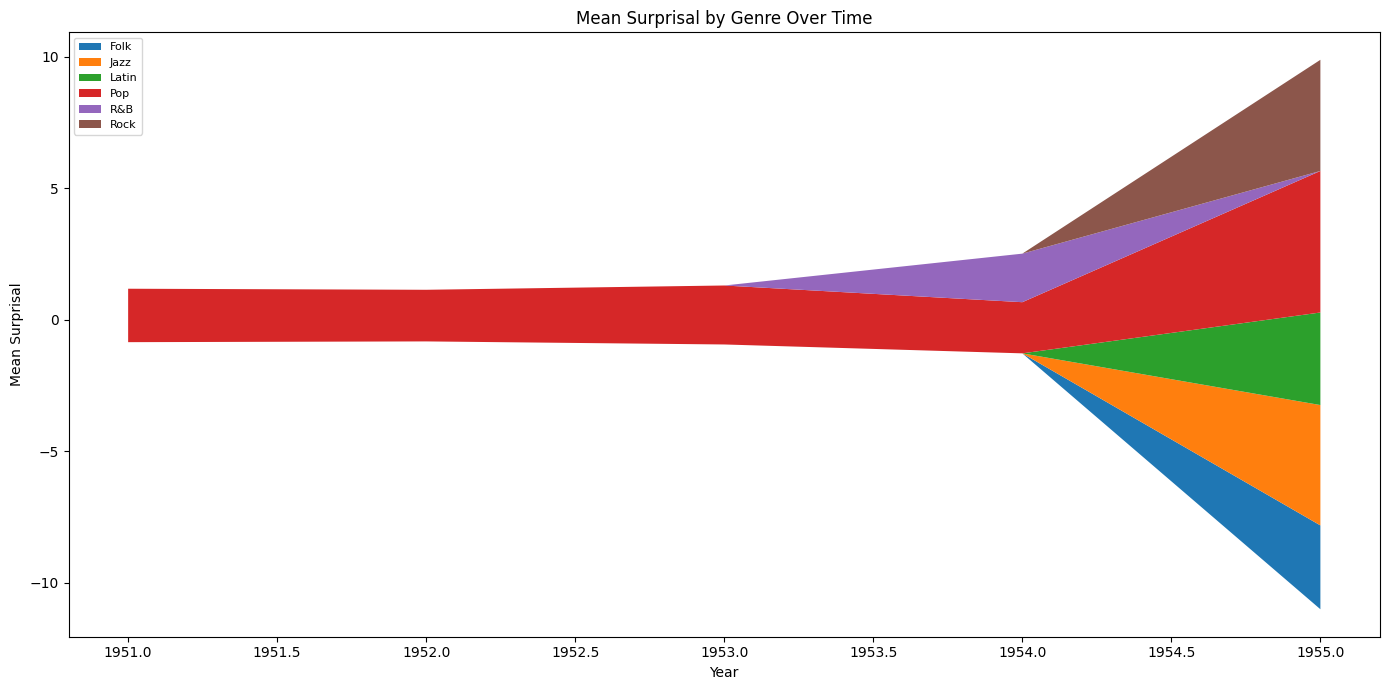

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Step 1: Extract year and aggregate by year + genre ---
merged_df["year"] = merged_df["year_position"].str[:4].astype(int)

yearly_genre = (
    merged_df.groupby(["year", "Genre (Broad 1)"])["mean_surprisal"]
    .mean()
    .reset_index()
)

# Pivot so genres are columns, years are rows
pivot_df = yearly_genre.pivot(index="year", columns="Genre (Broad 1)", values="mean_surprisal").fillna(0)

# --- Step 2: Plot streamgraph ---
years = pivot_df.index.values
genres = pivot_df.columns.tolist()
values = pivot_df.values.T  # shape: (n_genres, n_years)

fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(years, values, labels=genres, baseline="wiggle")  # "wiggle" gives the stream shape

ax.legend(loc="upper left", fontsize=8)
ax.set_title("Mean Surprisal by Genre Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Surprisal")

plt.tight_layout()
plt.show()

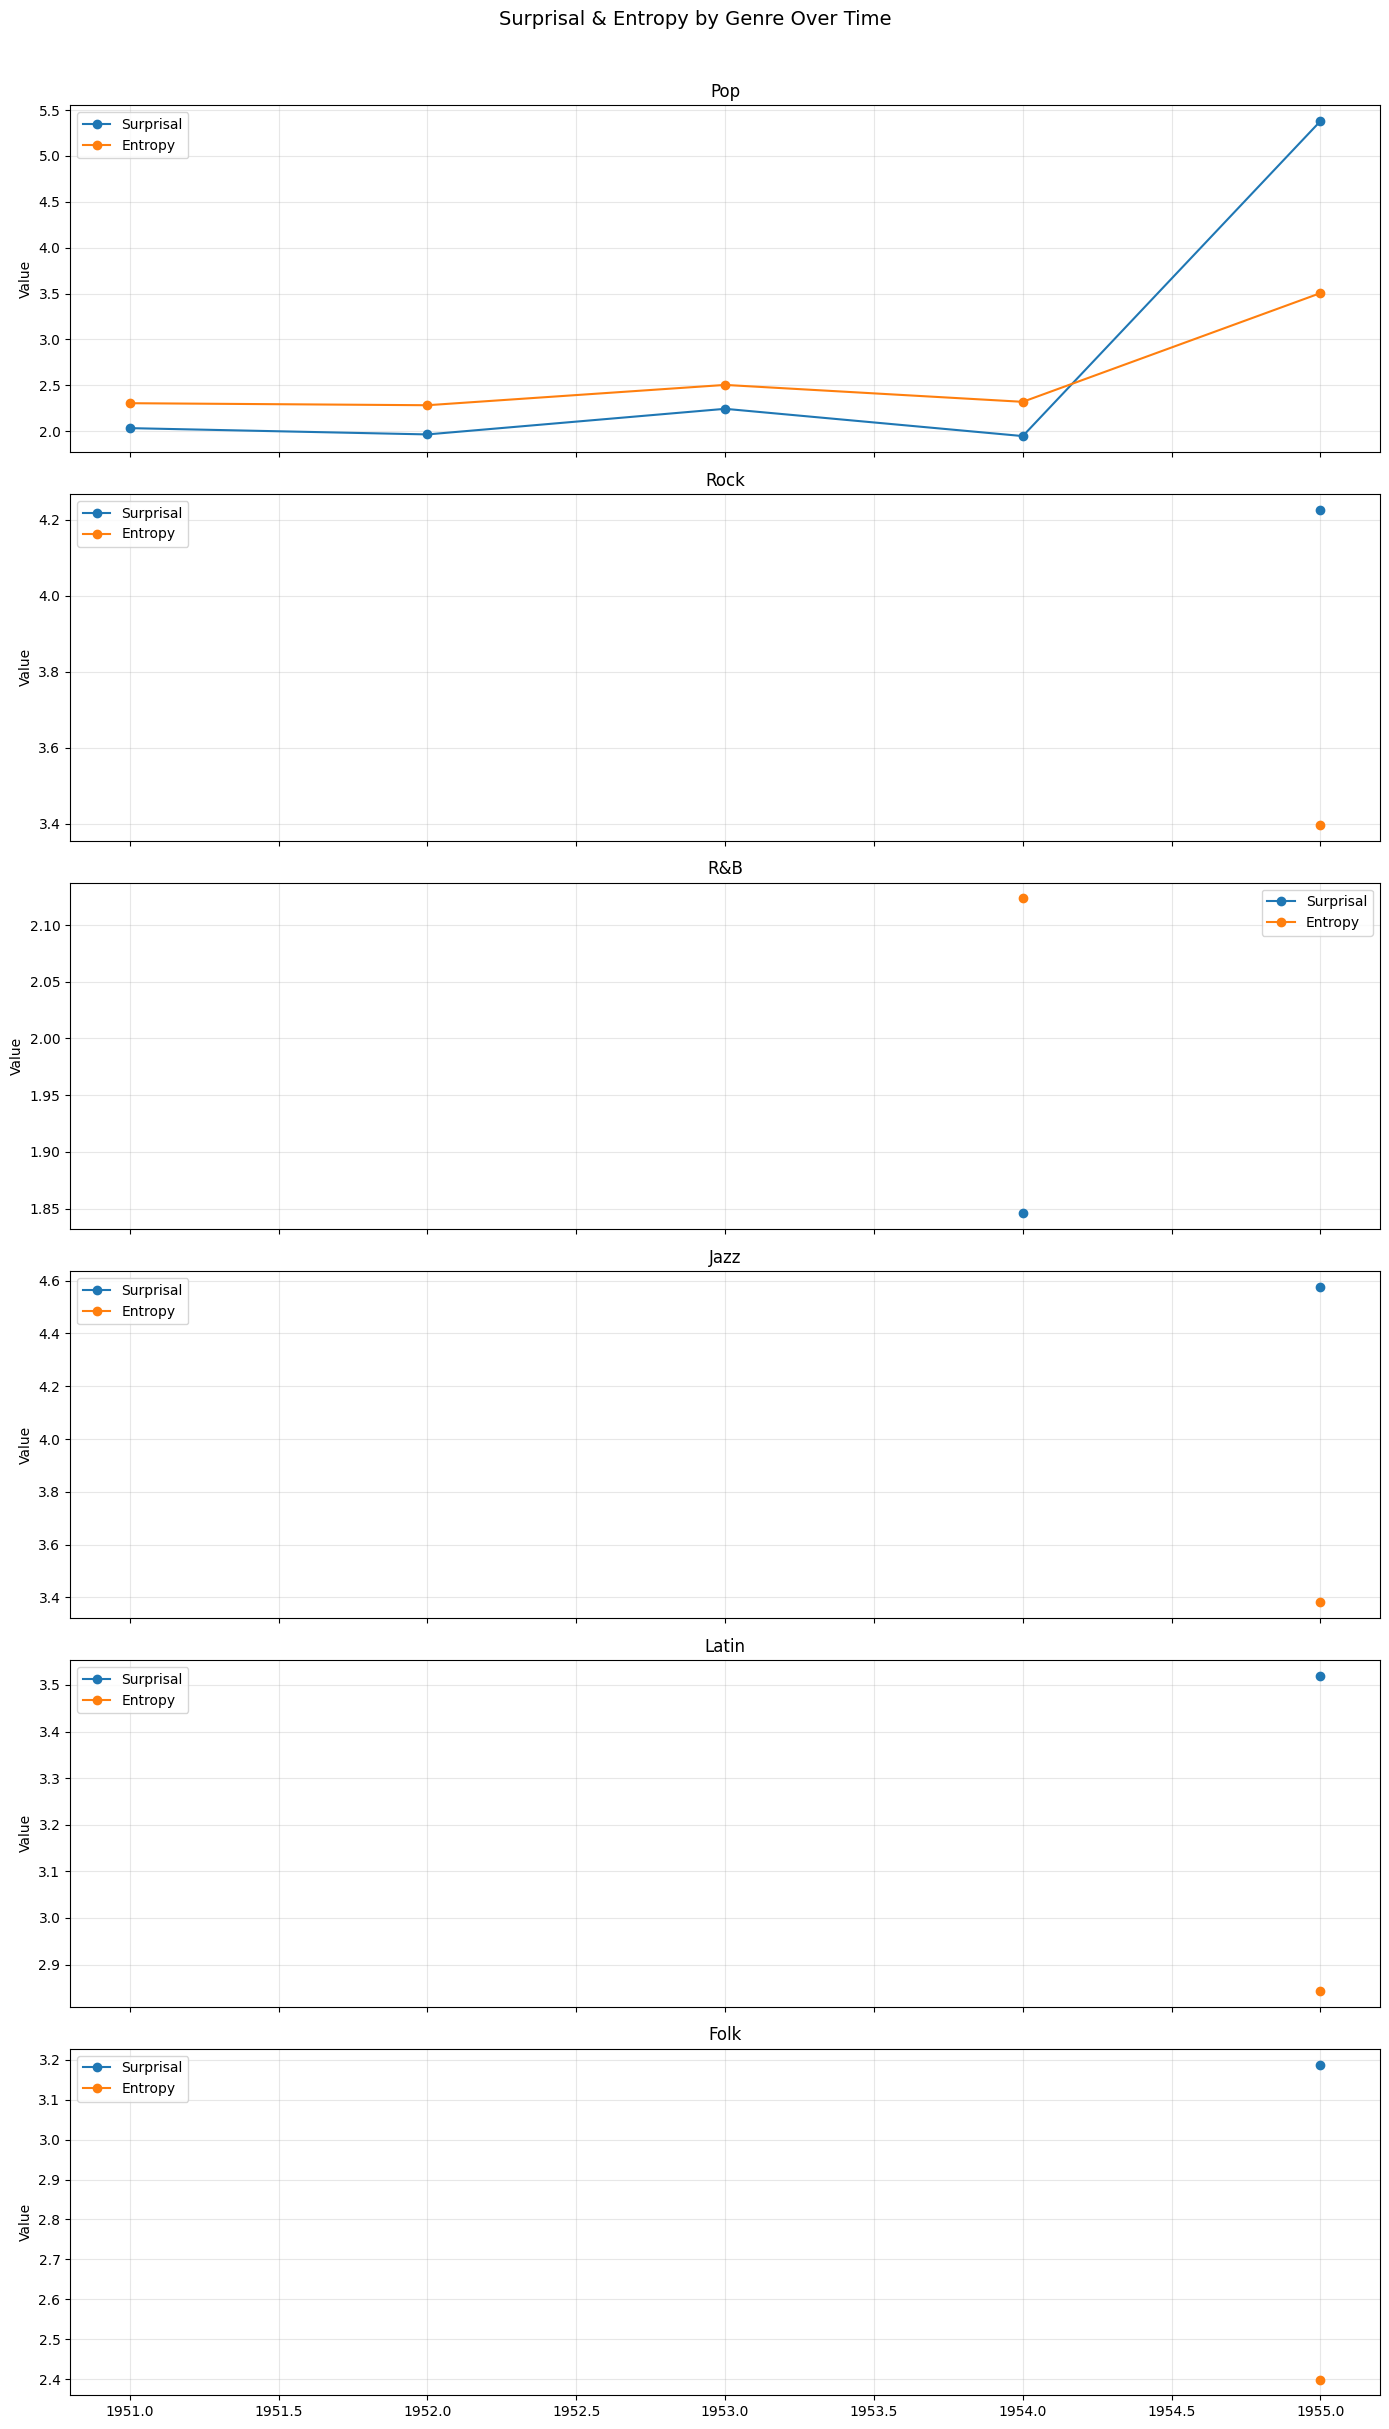

In [52]:
import matplotlib.pyplot as plt

genres = merged_df["Genre (Broad 1)"].dropna().unique()

fig, axes = plt.subplots(len(genres), 1, figsize=(14, 4 * len(genres)), sharex=True)

for ax, genre in zip(axes, genres):
    genre_df = merged_df[merged_df["Genre (Broad 1)"] == genre].copy()
    yearly = (
        genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    ax.plot(yearly["year"], yearly["mean_surprisal"], label="Surprisal", marker="o")
    ax.plot(yearly["year"], yearly["mean_entropy"], label="Entropy", marker="o")
    ax.set_title(genre)
    ax.set_ylabel("Value")
    # ax.set_xlabel("Year")
    ax.legend()
    ax.grid(True, alpha=0.3)

# axes[-1].set_xlabel("Year")
plt.suptitle("Surprisal & Entropy by Genre Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Extract the last year from each surprisal folder to see and compare the year's values

In [67]:
five_yr_lookback = []

for start_year in range(1950, 2020):  # adjust end year as needed
    end_year = start_year + 4
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"out/{folder_start}-{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)
        
    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    song_stats = []

    for song in df.columns:
        year = int(song[:4])  # extract year from filename
        
        surprisal_vector = df.loc[0, song]
        entropy_vector = df.loc[1, song]
        
        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)
        
        song_stats.append({
            "song": song,
            "year": year,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy
        })

    song_df = pd.DataFrame(song_stats)

    # --- Step 2: Aggregate by year ---
    yearly_stats = (
        song_df
        .groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )
    
    five_yr_lookback.append(yearly_stats.iloc[-1])
    
five_yr_lookback = pd.DataFrame(five_yr_lookback)
five_yr_lookback
    

,year,mean_surprisal,mean_entropy
4,1955.0,4.140432,3.094362
4,1956.0,5.107264,3.549987
4,1957.0,9.522592,3.398589
4,1958.0,4.795288,3.225394
4,1959.0,4.682121,3.499601
...,...,...,...
4,2020.0,3.911545,2.721305
4,2021.0,3.366579,2.513096
4,2022.0,3.521129,2.503355
4,2023.0,3.661760,2.769175


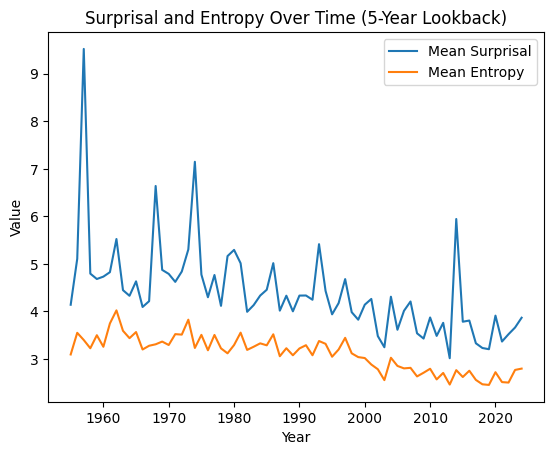

In [69]:
plt.figure()

plt.plot(five_yr_lookback["year"], five_yr_lookback["mean_surprisal"], label="Mean Surprisal")
plt.plot(five_yr_lookback["year"], five_yr_lookback["mean_entropy"], label="Mean Entropy")

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Surprisal and Entropy Over Time (5-Year Lookback)")
plt.legend()

plt.show()

### to do: 
- look into outliers 
- genre role it plays in the outliers / distribution per year 

- surprisal as a proxy for similarity (how surprising is rock to pop and vice versa)
- cluster with y axis suprrisal , x axis entropy,
